In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
amazon = pd.read_csv("../data/amazon_cells_labelled.txt", sep="\t", header=None, names=["review", "sentiment"])
yelp = pd.read_csv("../data/yelp_labelled.txt", sep="\t", header=None, names=["review", "sentiment"])
imdb = pd.read_csv("../data/imdb_labelled.txt", sep="\t", header=None, names=["review", "sentiment"])

amazon["source"] = "Amazon"
yelp["source"] = "Yelp"
imdb["source"] = "IMDB"

df = pd.concat([amazon, yelp, imdb], ignore_index=True)

df.head()

,review,sentiment,source
0,So there is no way for me to plug it in here i...,0,Amazon
1,"Good case, Excellent value.",1,Amazon
2,Great for the jawbone.,1,Amazon
3,Tied to charger for conversations lasting more...,0,Amazon
4,The mic is great.,1,Amazon


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     2748 non-null   object
 1   sentiment  2748 non-null   int64 
 2   source     2748 non-null   object
dtypes: int64(1), object(2)
memory usage: 64.5+ KB


In [4]:
df["sentiment"].value_counts()

sentiment
1    1386
0    1362
Name: count, dtype: int64

In [5]:
df["source"].value_counts()

source
Amazon    1000
Yelp      1000
IMDB       748
Name: count, dtype: int64

In [6]:
import re

def clean_review(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["cleaned_review"] = df["review"].apply(clean_review)

df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...
1,"Good case, Excellent value.",good case excellent value
2,Great for the jawbone.,great for the jawbone
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...
4,The mic is great.,the mic is great


In [7]:
from collections import Counter

negative_reviews = df[df["sentiment"] == 0]

all_words = " ".join(negative_reviews["cleaned_review"])

words = all_words.split()

common_words = Counter(words).most_common(20)

common_words

[('the', 986),
 ('i', 476),
 ('and', 468),
 ('a', 438),
 ('to', 380),
 ('it', 369),
 ('is', 357),
 ('of', 336),
 ('this', 323),
 ('was', 322),
 ('not', 252),
 ('in', 197),
 ('for', 184),
 ('that', 179),
 ('my', 128),
 ('with', 118),
 ('but', 117),
 ('you', 113),
 ('on', 110),
 ('very', 101)]

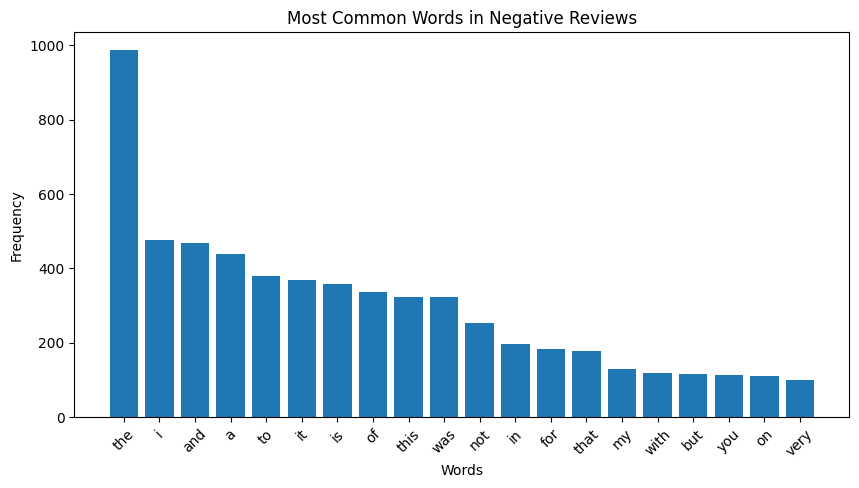

In [8]:
words_df = pd.DataFrame(common_words, columns=["word", "count"])

plt.figure(figsize=(10,5))
plt.bar(words_df["word"], words_df["count"])
plt.xticks(rotation=45)
plt.title("Most Common Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [9]:
negative_reviews = df[df["sentiment"] == 0]

all_words = " ".join(negative_reviews["cleaned_review"])

words = all_words.split()

words[:10]

['so', 'there', 'is', 'no', 'way', 'for', 'me', 'to', 'plug', 'it']

In [10]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

filtered_words = [
    word for word in words
    if word not in ENGLISH_STOP_WORDS
]

common_filtered_words = Counter(filtered_words).most_common(20)

common_filtered_words

[('movie', 93),
 ('bad', 92),
 ('phone', 76),
 ('film', 71),
 ('just', 69),
 ('dont', 66),
 ('like', 65),
 ('food', 64),
 ('time', 61),
 ('place', 56),
 ('good', 56),
 ('service', 52),
 ('really', 43),
 ('work', 39),
 ('worst', 38),
 ('didnt', 35),
 ('im', 34),
 ('waste', 32),
 ('money', 30),
 ('terrible', 30)]

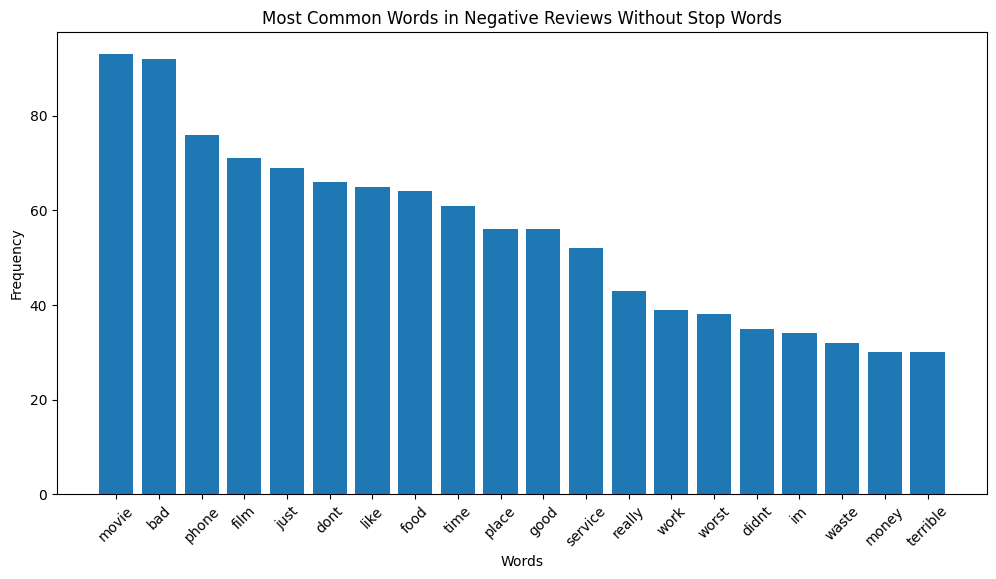

In [22]:
filtered_df = pd.DataFrame(common_filtered_words, columns=["word", "count"])

plt.figure(figsize=(12,6))
plt.bar(filtered_df["word"], filtered_df["count"])

plt.title("Most Common Words in Negative Reviews Without Stop Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.savefig("../images/negative_words_chart.png")

plt.show()

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["cleaned_review"])

y = df["sentiment"]

X.shape

(2748, 5283)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape

(2198, 5283)

In [14]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [15]:
predictions = model.predict(X_test)

predictions[:10]

array([1, 0, 1, 1, 0, 0, 1, 0, 0, 0])

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7927272727272727


In [17]:
custom_review = ["This product is amazing and works perfectly"]

custom_review_cleaned = [clean_review(review) for review in custom_review]

custom_review_vectorized = vectorizer.transform(custom_review_cleaned)

prediction = model.predict(custom_review_vectorized)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [19]:
custom_review = ["This phone battery dies too fast and I hate it"]

custom_review_cleaned = [clean_review(review) for review in custom_review]

custom_review_vectorized = vectorizer.transform(custom_review_cleaned)

prediction = model.predict(custom_review_vectorized)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Negative Review


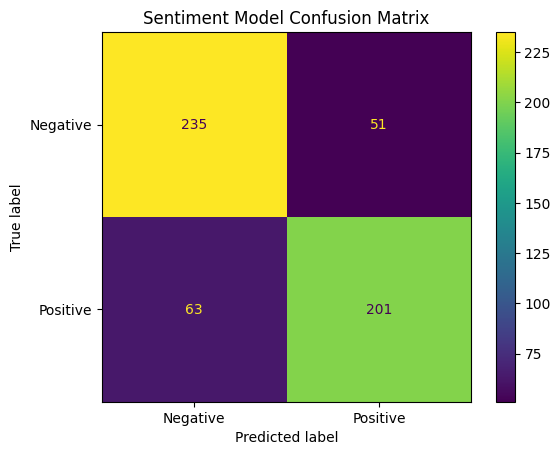

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot()
plt.title("Sentiment Model Confusion Matrix")

plt.savefig("../images/confusion_matrix.png")

plt.show()

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.79      0.82      0.80       286
    Positive       0.80      0.76      0.78       264

    accuracy                           0.79       550
   macro avg       0.79      0.79      0.79       550
weighted avg       0.79      0.79      0.79       550



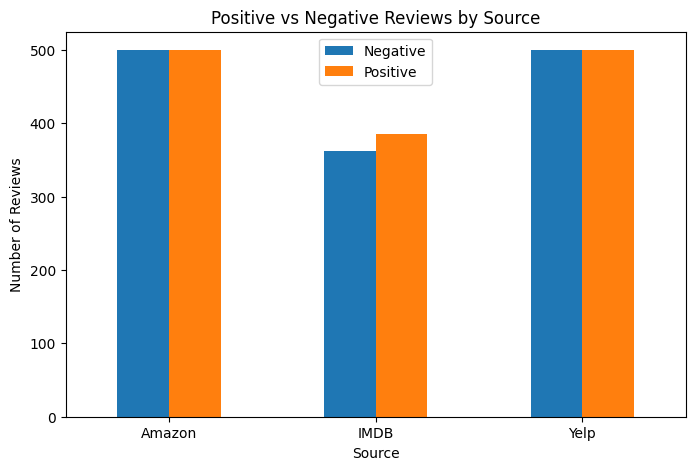

In [24]:
sentiment_by_source = pd.crosstab(df["source"], df["sentiment"])

sentiment_by_source.columns = ["Negative", "Positive"]

sentiment_by_source.plot(kind="bar", figsize=(8,5))

plt.title("Positive vs Negative Reviews by Source")
plt.xlabel("Source")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)

plt.savefig("../images/sentiment_by_source.png")

plt.show()

# Customer Review Sentiment Analysis Using Python

## Project Overview
This project analyzes customer reviews from Amazon, Yelp, and IMDB using Natural Language Processing (NLP) and machine learning techniques.

## Tools Used
- Python
- pandas
- matplotlib
- scikit-learn
- Jupyter Notebook

## Objectives
- Clean and preprocess review text
- Analyze common negative review patterns
- Visualize sentiment trends
- Build a sentiment prediction model
- Evaluate model performance

# Key Insights

- Negative reviews frequently contained words such as "bad", "worst", and "disappointing".
- Yelp reviews showed a higher concentration of negative feedback compared to other platforms.
- Text preprocessing improved analysis quality by removing punctuation and stop words.
- The machine learning model successfully predicted customer sentiment with strong accuracy.